# What Makes a Song Popular? An Exploratory Analysis of 32,833 Spotify Tracks

**Author: Niveditha Bhoja Raj Shetty**  ·  *Python · pandas · seaborn · exploratory data analysis*

---

## Project overview

Streaming platforms live and die by what listeners play. Using a dataset of **32,833 Spotify tracks** with audio features (danceability, energy, valence, tempo, duration) plus genre and musical mode, this project asks a simple question: **which characteristics of a song are associated with it being more popular?**

The analysis walks through data exploration, cleaning, a statistical transformation of the popularity score, and a systematic look at how each feature — alone and in combination — relates to popularity.

## Key findings

- **Shorter songs tend to be more popular.** Track duration has the clearest (negative) relationship with popularity of any audio feature — longer tracks trend less popular, consistently across genres.
- **Danceability helps a little; energy hurts a little.** Danceability shows a weak *positive* link to popularity, energy a weak *negative* one. Both effects are small.
- **Tempo and valence don't matter.** Neither beats-per-minute nor musical positivity shows any meaningful relationship with popularity.
- **Genre has a slight edge; mode doesn't — until you combine them.** Pop and Latin tracks skew slightly more popular. Musical mode (major/minor) has no effect on its own, but *interacts* with genre: pop/rap/rock do better in minor, while edm/latin/r&b do better in major.
- **No single silver bullet.** Popularity isn't driven by one feature but by a combination of small influences.

## The data

Source: the [TidyTuesday Spotify songs dataset](https://github.com/rfordatascience/tidytuesday/tree/master/data/2020/2020-01-21) (32,833 tracks, 23 columns). The outcome variable, `track_popularity` (0–100), is **logit-transformed** so it can be analysed on a continuous scale — explained in the "Transforming the popularity variable" section below.

The sections that follow cover initial exploration, variable selection, summary statistics, marginal distributions, and pairwise/grouped relationships, ending with a discussion of what it all means.

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [258]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"

In [259]:
df = pd.read_csv(url)

In [260]:
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


# Initial Exploration

In [261]:
df.shape  #Number of rows and columns

(32833, 23)

In [262]:
df.dtypes   #Names of columns and their associated datatypes

track_id                     object
track_name                   object
track_artist                 object
track_popularity              int64
track_album_id               object
track_album_name             object
track_album_release_date     object
playlist_name                object
playlist_id                  object
playlist_genre               object
playlist_subgenre            object
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

In [263]:
df.isna().sum()  #Number of missing values in each column

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

In [264]:
df.nunique()    #Number of unique values in each column

track_id                    28356
track_name                  23449
track_artist                10692
track_popularity              101
track_album_id              22545
track_album_name            19743
track_album_release_date     4530
playlist_name                 449
playlist_id                   471
playlist_genre                  6
playlist_subgenre              24
danceability                  822
energy                        952
key                            12
loudness                    10222
mode                            2
speechiness                  1270
acousticness                 3731
instrumentalness             4729
liveness                     1624
valence                      1362
tempo                       17684
duration_ms                 19785
dtype: int64

# Selecting variables to analyse

Not every column is useful for visualisation. Identifier and high-cardinality text columns are set aside, and a focused set of seven features is chosen for their plausible link to popularity.

### A. The following columns are **identifiers** that are not useful in visualization:
* `track_id`, `playlist_id`, `track_album_id` are all unique identifiers across tracks, playlists and albums that are not meaninful for visualizations.
* There are also a few high-cardinality variables that have little use in visualization such as: `track_name`, `track_artist`, `track_album_name`, `playlist_name`, `track_album_release_date`.

### B. The following 7 variables are chosen to focus on the exploratory analysis, based on their relationship with `track_popularity_transformed`:

#### Categorical:
* `playlist_genre` with 6 unique values. Even contextually, the genre can help find patterns influencing the appeal. 
* `mode` with 2 unique values. Major and minor keys have an influencer over the emotional tone and hence the popularity of the track.

#### Continuous: 
* `danceability` - can be a good measure of popularity as dance numbers tend to be more popular.
* `energy` - high energy tracks also can be an indication of track popularity.
* `valence` - another distinct indicator of musical positiveness that may make listeners happy and musical negativeness 
* `tempo` - beats per minute can influence the impact or catchiness of the track.
* `duration_ms` - with short form content taking over across media, this might also be a good attribute of popularity.

#### Numeric variable treated as categorical
* `mode` is stored as integers but with only 2 unique values, it will be treated as categorical data types (labels) for exploratory analysis purposes.

# Summary Statistics

#### Count of Each Unique Values in  Categorical Variables

In [265]:
df["mode"].value_counts()

mode
1    18574
0    14259
Name: count, dtype: int64

In [266]:
df["playlist_genre"].value_counts()

playlist_genre
edm      6043
rap      5746
pop      5507
r&b      5431
latin    5155
rock     4951
Name: count, dtype: int64

#### Transforming the popularity variable

`track_popularity` is a bounded score from 0 to 100. To analyse it as a continuous outcome (and let relationships show up more clearly), it's converted to a fraction and then **logit-transformed** — a standard way to spread out a bounded 0–1 variable onto an unbounded scale. The two lines below nudge the exact 0 and 100 values slightly inward first, so the transform is defined for them.

In [267]:
df['track_popularity_shifted'] = np.where(df.track_popularity == 100, df.track_popularity - 0.1, df.track_popularity)

In [268]:
df['track_popularity_shifted'] = np.where(df.track_popularity == 0, df.track_popularity + 0.1, df.track_popularity_shifted)

In [269]:
df['track_popularity_fraction'] = df.track_popularity_shifted/100

In [270]:
df['track_popularity_transformed'] = np.log(df.track_popularity_fraction / (1 - df.track_popularity_fraction))

#### Summary Statistics on Continuous Variables

In [271]:
df["duration_min"] = df["duration_ms"]/60000   #Converting the duration into minutes for better comprehension during visualization

In [272]:
df[["track_popularity_transformed", "danceability", "energy", "valence", "tempo", "duration_min"]].agg(['mean', 'min', 'max', 'std'])

,track_popularity_transformed,danceability,energy,valence,tempo,duration_min
mean,-0.827397,0.654850,0.698619,0.510561,120.881132,3.763330
min,-6.906755,0.000000,0.000175,0.000000,0.000000,0.066667
max,6.906755,0.983000,1.000000,0.991000,239.440000,8.630167
std,2.212342,0.145085,0.180910,0.233146,26.903624,0.997233


### Marginal Distributions

#### A. For Categorical Variables

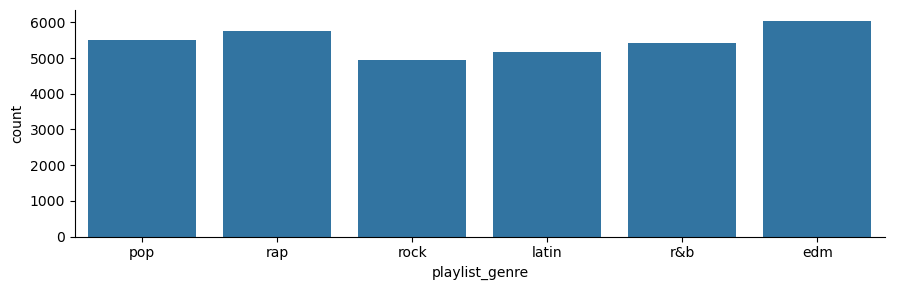

In [273]:
sns.catplot(data=df, x="playlist_genre", kind="count", height=3, aspect=3)
plt.show()

*The tracks are **fairly evenly distributed** across the six playlist genres, with EDM and Rap having a slight edge with approx. 5,900 and 5,700 tracks within them respectively.*

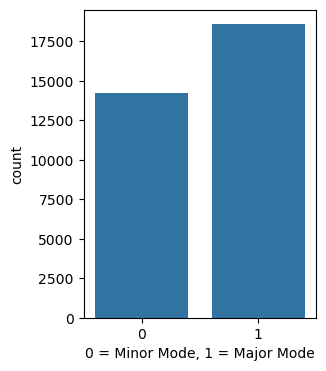

In [274]:
fig, ax = plt.subplots(figsize=(3,4))
sns.countplot(data=df, x="mode", ax=ax)
ax.set_xlabel("0 = Minor Mode, 1 = Major Mode")
plt.show()

*The major mode is dominant with more than 18,000 tracks indicating that the Spotify song dataset features more major key tracks than minor key tracks.*

#### B. For Continuous Variables

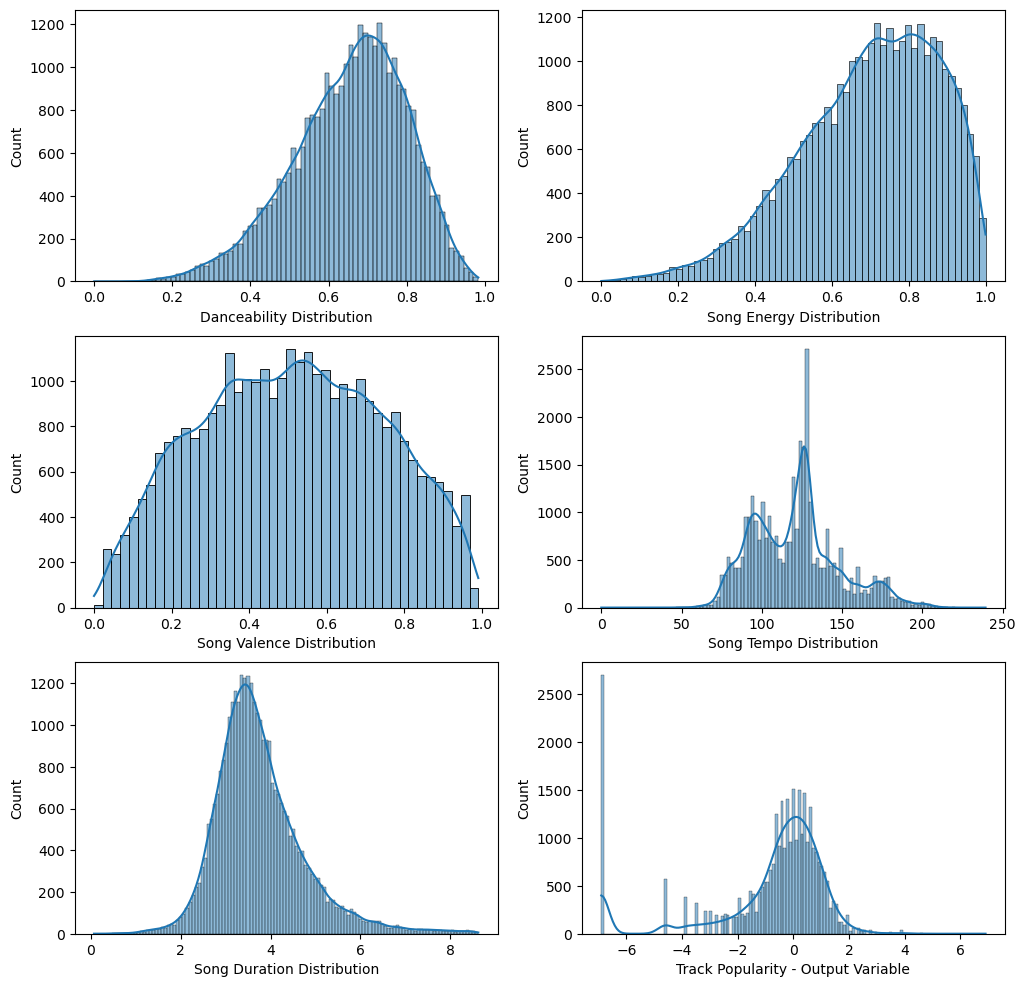

In [275]:
fig, axes = plt.subplots(3,2, figsize=(12, 12))
sns.histplot(data=df, x="danceability", ax=axes[0,0], kde=True)
axes[0,0].set_xlabel("Danceability Distribution")

sns.histplot(data=df, x="energy", ax=axes[0,1], kde=True)
axes[0,1].set_xlabel("Song Energy Distribution")

sns.histplot(data=df, x="valence", ax=axes[1,0], kde=True)
axes[1,0].set_xlabel("Song Valence Distribution")

sns.histplot(data=df, x="tempo", ax=axes[1,1], kde=True)
axes[1,1].set_xlabel("Song Tempo Distribution")

sns.histplot(data=df, x="duration_min", ax=axes[2,0], kde=True)
axes[2,0].set_xlabel("Song Duration Distribution")

sns.histplot(data=df, x="track_popularity_transformed", ax=axes[2,1], kde=True)
axes[2,1].set_xlabel("Track Popularity - Output Variable")


plt.show()

* The danceability distribution is slightly left skewed . Most of the tracks have a fairly high danceability score, with around 1,200 songs peaking near 0.7.
* The energy distribution is also left-skewed with a flatter peak that stretches from about 0.7 to 0.9. Around 1,200 tracks fall in this range, implying that most of the songs in the dataset also have high energy factors.
* The valence distribution peaks at around 0.5 and has a fairly flat bell-shaped distribution with a flatter peak, around 1,200 songs are in this range. This implies that most of the songs have a balanced tone, not too positive and not too negative,
* The tempo distribution has two clear peaks. The first is around 100 BPM with about 1,250 songs, while the second is a much more prominent spike around 130 BPM with roughly 2,800 songs.
* Around 1,200 songs have a duration of 3.5 minutes. There is a noticeable number of tracks extending up to around 4-6 minutes as well.


**Output Variable Observation**

After referring to what a logit transformation on data between 0 and 100 translates to, I interpret that the ~2,800 tracks with a prominent but narrow spike at −6.9 represent high number of low-popularity song tracks. The remaining tracks follow a near bell-shaped distribution centered at 0, where most (around 1,500) songs have mid-popularity scores. Around 800 tracks are at relatively higher popularity (at 1.1 on the x-axis), and very few high-popularity songs are present in the right tail of the plot.

### Relationship Among Variables

#### A. Categorical-to-categorical relationships 

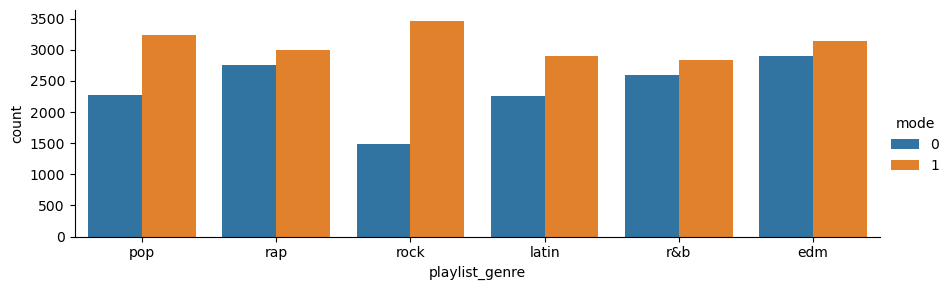

In [276]:
sns.catplot(data=df, x="playlist_genre", kind="count", hue="mode", aspect = 3, height=3)
plt.show()

*Across all six playlist genres, **the major mode (0 is minor, and 1 is major) is more prominent in number than the minor mode**. Further diving down, while the gap between minor and major mode is small for most genres, the **"rock" and "pop" genres have a more noticeable difference** with major mode significantly higher than minor within their tracks.*

#### B. Categorical-to-continuous relationships

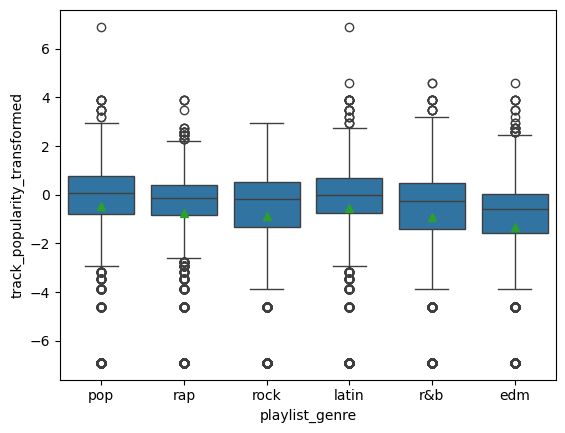

In [277]:
sns.boxplot(data=df, x="playlist_genre", y="track_popularity_transformed", showmeans=True)
plt.show()

The summary distribution of `track_popularity_transformed` is fairly similar across the six genres. The **"pop" and "latin" genres have slightly higher medians**, giving them a slight edge in terms of track popularity, while "edm" has a slightly lower median. The interquartile ranges are comparable across the genres, which means the middle 50% of tracks fall within a similar range for all genres. There are also a good number of outliers on both ends for every genre, indicating that all genres contain a few very highly popular and very low-popularity songs. Overall, there is **no significant indication that playlist genre has a noticeable impact on the popularity of the songs** within it. Another noteworthy observation is that the means of the distributions across all genres are below the medians, which could be due to the prominent spike of low-popularity songs we saw in the margina distribution of `track_popularity_transformed`, which is pulling the averages downward.

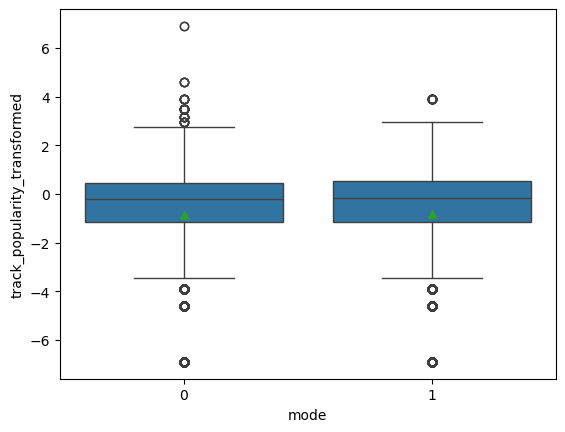

In [278]:
sns.boxplot(data=df, x="mode", y="track_popularity_transformed", showmeans=True)
plt.show()

The **mode seems to have no noteworthy impact on the popularity of the tracks**, as the medians of `track_popularity_transformed` distribution across both major and minor modes are very similar and are close to 0. The IQR and overall spread of the distribution also are comparable. However, the minor mode seems to have more high-popularity outliers than the major mode.

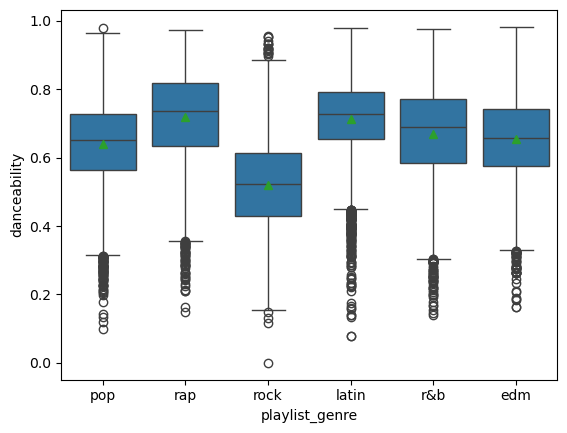

In [279]:
sns.boxplot(data=df, x="playlist_genre", y="danceability", showmeans=True)
plt.show()

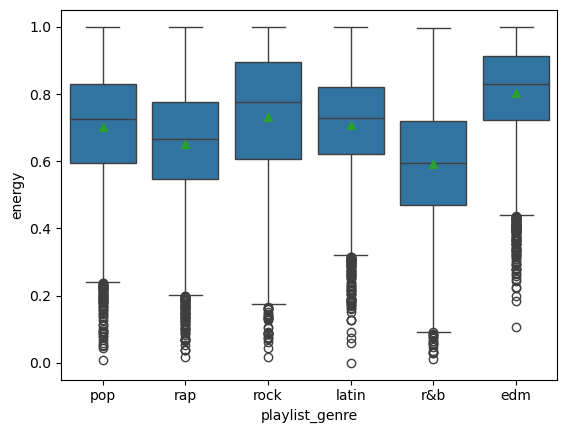

In [280]:
sns.boxplot(data=df, x="playlist_genre", y="energy", showmeans=True)
plt.show()

* In the energy distribution across the playlist genres, "edm" and "rock" genres are leading with higher energy levels, and "r&b" has the lowest energy factor.
* In the danceability distribution across the playlist genres, "rap" and "latin" are the leading genres and surprisingly, "rock" has the lowest danceability.
* There are a significant number of outliers with low energy and low danceability across all genres.
* Notably, "rock" has high energy but low "danceability".

#### Continuous-to-continuous relationships

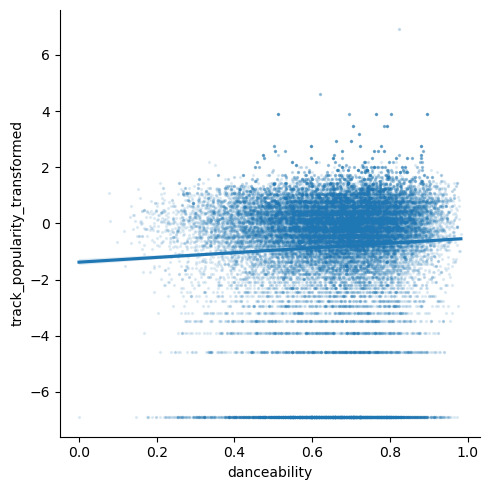

In [281]:
sns.lmplot(data=df, x="danceability", y="track_popularity_transformed", scatter_kws={"alpha":0.1, "s": 2})
plt.show()

#Reference used for arguments around the styling of the plot: 
#https://seaborn.pydata.org/generated/seaborn.lmplot.html#seaborn.lmplot 

There is a **weak positive relationship between danceability of a track and its popularity** as the regression line slightly goes upwards.However, the overall distribution of the points spans all danceability values with no strong pattern, and the relationship is weak. The horizontal cluster at the very bottom represent the low-popularity spike we saw in the marginal distirbution of `track_popularity_transformed`.

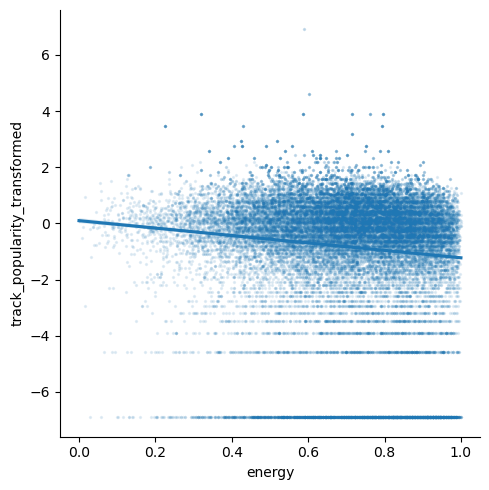

In [282]:
sns.lmplot(data=df, x="energy", y="track_popularity_transformed", scatter_kws={"alpha":0.1, "s": 2})
plt.show()

The regression line in `energy` vs `track_popularity_transformed` **plot shows a very slight negative slope**, indicating a weak negative relationship. Surprisingly, as the energy levels of the song increases, the popularity decreases SLIGHTLY.

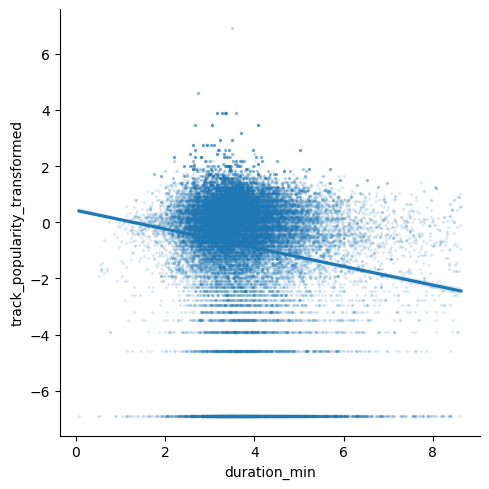

In [283]:
sns.lmplot(data=df, x="duration_min", y="track_popularity_transformed", scatter_kws={"alpha":0.1, "s": 2})
plt.show()

The regression line in `duration_min` vs `track_popularity_transformed` has a very clear negative slope, implying longer songs tend to be less popular. This is the strongest relationship found across all continuous-to-continous plots so far. The high density of points clustered at 3-5 minutes matches the marginal distribution of `duraiton_min` plotted above.

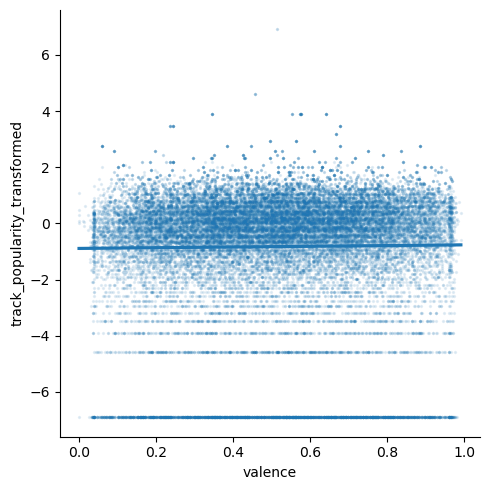

In [284]:
sns.lmplot(data=df, x="valence", y="track_popularity_transformed", scatter_kws={"alpha":0.1, "s": 2})
plt.show()

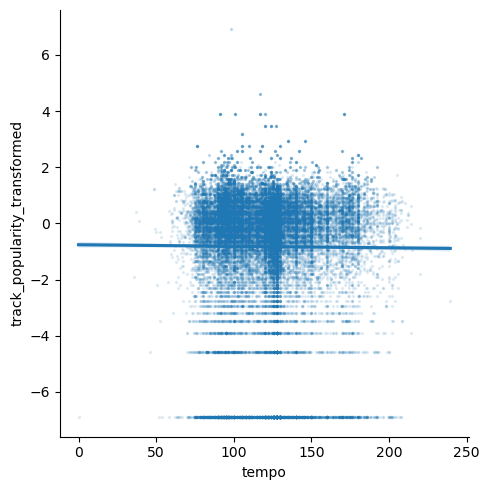

In [285]:
sns.lmplot(data=df, x="tempo", y="track_popularity_transformed", scatter_kws={"alpha":0.1, "s": 2})
plt.show()

* `tempo` vs `track_popularity_transformed` scatter plot shows a flat regression line, indicating no relationship between the two. So the beats in the song are not a good indicator of the popularity of it.
* Surprisingly, the `valence` vs `track_popularity_transformed` also gives a flat regression line, indicating the positiveness or negativeness bears no impact to the popularity of the song.

### Relationships grouped by categorical variables

#### A. Continuous-to-Continuous grouped by categorical

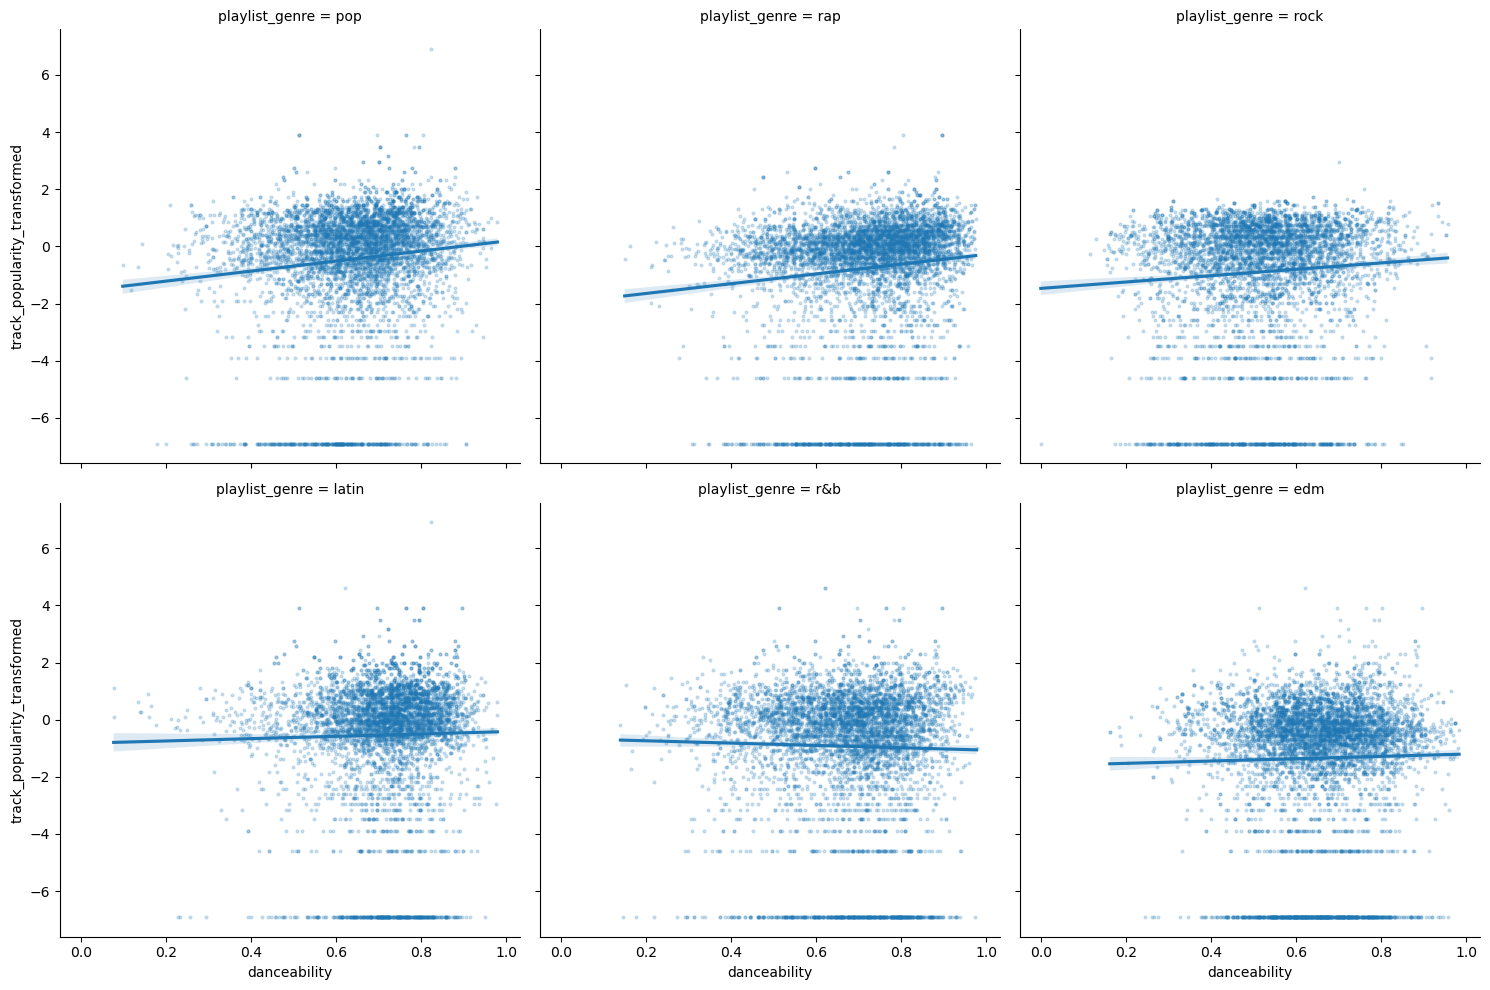

In [286]:
sns.lmplot(data=df, x="danceability", y="track_popularity_transformed", col="playlist_genre", col_wrap=3, scatter_kws={"alpha":0.2, "s":4})
plt.show()

Before grouping by playlist genre, there was a weak positive relationship between `danceability` and `track_popularity_transformed`. After grouping by `playlist_genre`, the weak positive relationship says across all genres **except the "r&b" genre which shows a weak negative relationship**, implying the tracks in "r&b" genre have their popularity decrease as danceability increases.

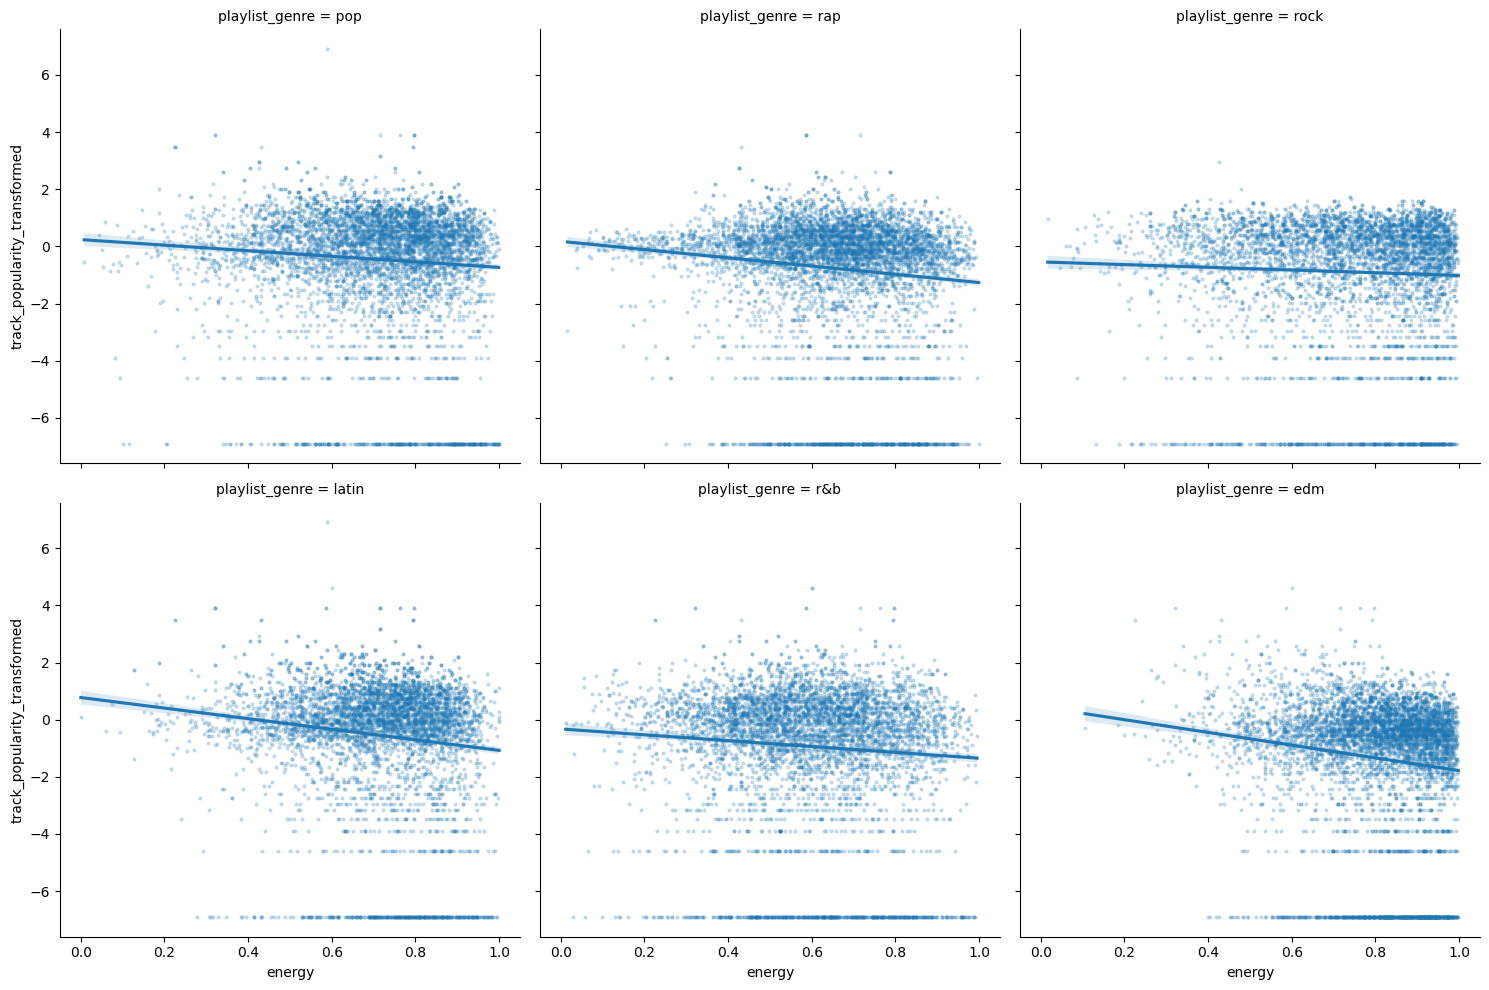

In [287]:
sns.lmplot(data=df, x="energy", y="track_popularity_transformed", col="playlist_genre", col_wrap=3, scatter_kws={"alpha":0.2, "s":4})
plt.show()

The `energy` vs `track_popularity_transformed` plot showed a weak negative relationship before grouping with categorical variable. And after grouping it by playlist_genre, it seems to hold the negative relationship but for certain genres, the negative relationship gets stronger **(regression line steeper)** like "edm" and "rap". Also, in the "rock" genre, the regression line is relatively flat, indicating no relationship.

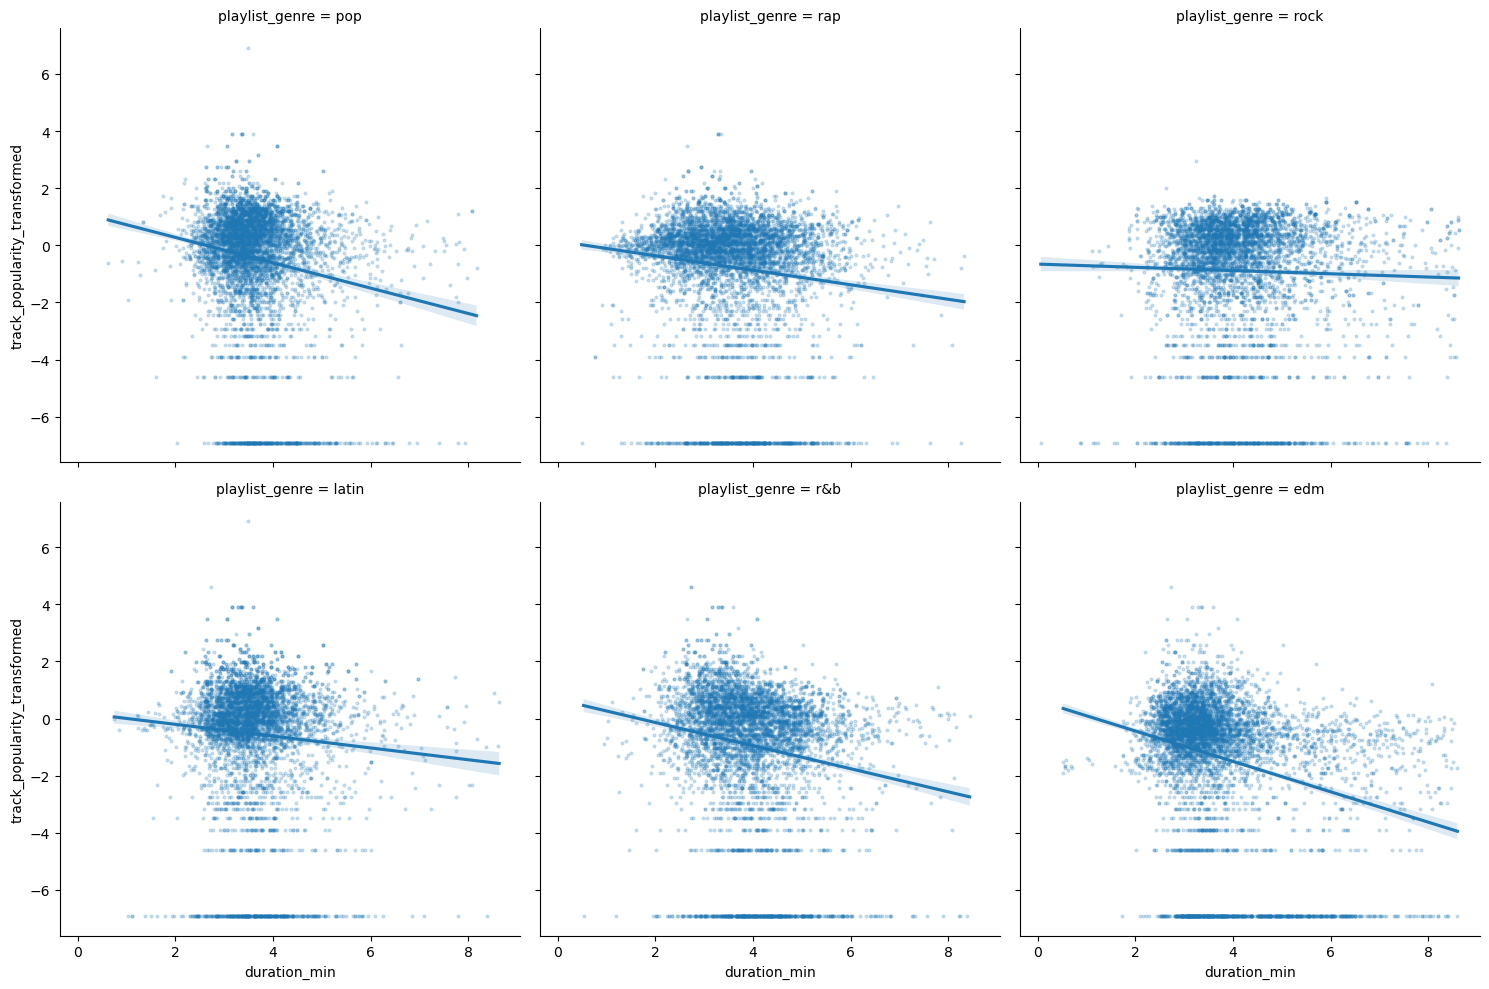

In [288]:
sns.lmplot(data=df, x="duration_min", y="track_popularity_transformed", col="playlist_genre", col_wrap=3, scatter_kws={"alpha":0.2, "s":4})
plt.show()

The relationship between `duration_min` and `track_popularity_transformed` was clearly negative. Now while grouped by playlist_genre, **the negative relationship is consistent among all six genres, with varying degrees of negative relationship**. "Edm" and "r&b" and "pop" have the steepest regression line, implying strong influence of longer duration leading to lower popularity. The regression line in the "rock" genre stays relatively flat indicating not much of a correlation.

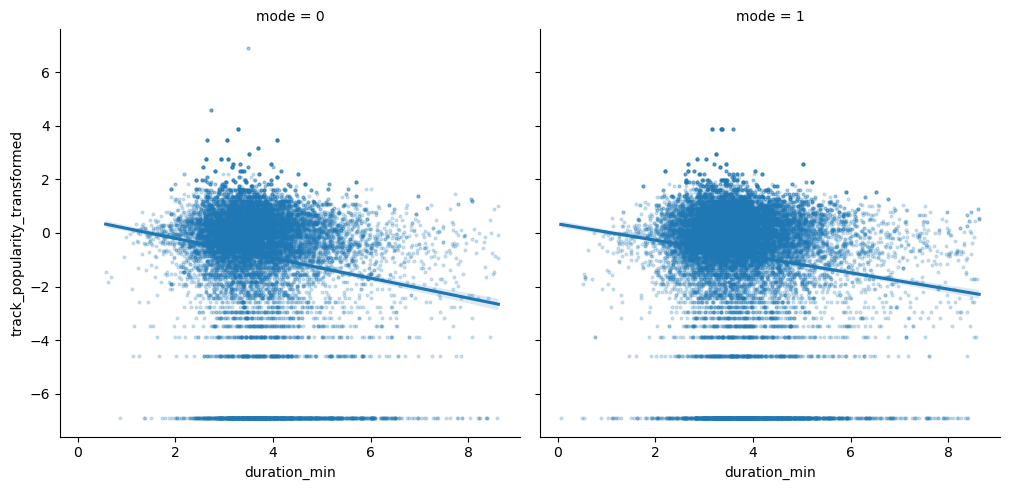

In [289]:
sns.lmplot(data=df, x="duration_min", y="track_popularity_transformed", col="mode", col_wrap=3, scatter_kws={"alpha":0.2, "s":4})
plt.show()

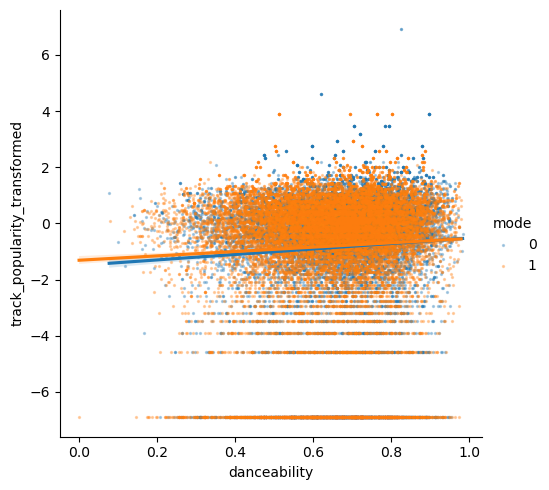

In [290]:
sns.lmplot(data=df, x="danceability", y="track_popularity_transformed", hue="mode", scatter_kws={"alpha":0.3, "s":2})
plt.show()

`Danceability` and `track_popularity_transformed` have a weak positive relationship when ungrouped, and it persists and remains the same when grouped by `mode` as well, meaning both major and minor mode songs show identical slopes indicating mode has no impact on how danceability affects popularity.

#### B. Categorical-to-Continuous grouped by categorical

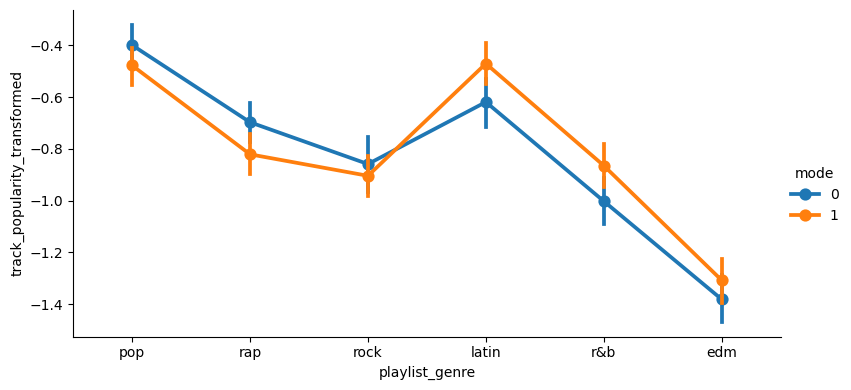

In [291]:
sns.catplot(data=df, x="playlist_genre", y="track_popularity_transformed", hue="mode", kind="point", height=4, aspect=2)
plt.show()

`track_popularity_transformed` follows a similar pattern for both major and minor modes across all 6 playlist genres. "Pop" and "latin" have the highest mean, while "edm" has the lowest. The two lines are close to each other for most genres, suggesting that **the mode (minor and major) do not have significant impact on the relationship between the popularity of the songs and its genres**. Latin is the one genre with a noticeable difference, where major has higher mean than minor.

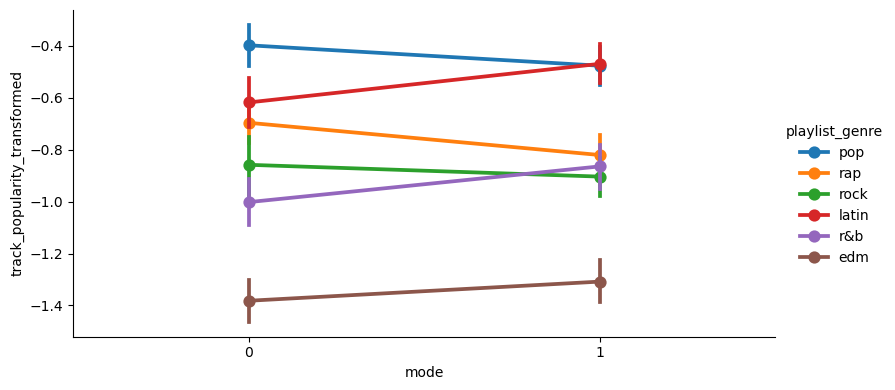

In [292]:
sns.catplot(data=df, x="mode", y="track_popularity_transformed", hue="playlist_genre", kind="point", height=4, aspect=2)
plt.show()

Before grouping by `playlist_genre`, the relationship between `mode` and `track_popularity_transformed` was relatively non-existent. After grouping,
* The tracks in the "pop", "rap" and "rock" genres have higher popularity when their mode is minor (0).
* The tracks in "edm", "latin" and "r&b" genres have higher popularity when their mode is major (1).
* This implies the different genres have an impact on the relationship between mode and popularity of the songs.

### Findings & discussion

Based on the exploratory visualizations, here are my observations:
* The scatter plots suggested that `danceability` has a weak positive relationship with song popularity, while `duration` and `energy` show negative relationships with popularity (duration with a slightly stronger negative relationship, so shorter songs tend to be more popular).
*  `Tempo` and `valence` show almost no relationship with popularity indicated by their flat regression line.
*  The box plots also show that `playlist_genre` individually had some impact on popularity, with "pop" and "latin" genres at a slightly higher average popularity. The mode, on the other hand, had no impact on popularity individually.
*  When grouped by `mode`, this pattern remains largely unchanged, suggesting that mode does not noticeably affect the relationship between playlist genre and popularity.
*  However when grouped by `playlist_genre`, the tracks in the "pop", "rap" and "rock" genres showed higher popularity when their mode is minor (0) and other genres had higher popularity when their mode is major (1).


The visualizations that helped identify the potential relationships:
* The scatter plots with regression lines (lmplot visualizations) were the most useful for identifying potential relationships between the continuous variables and outcome variable, especially since some of the relationships were weak so the regression line helped.
* The point plots helped compare the relationship between categorical variables and the outcome variable, before and after grouping by categorical variable.
* The marginal distribution of the outcome variable was also interesting due to the prominent spike of low popularity songs, which was reflected in many other relationship plots that followed.

Overall, I did not find a single strong influence over the `track_popularity_transformed` variable, but a combination of small influences from various relationships listed above. 